In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.signal import fftconvolve, welch
from scipy.optimize import curve_fit
from scipy.stats import norm
import functions as ft
import re
from natsort import natsorted
from glob import glob
import matplotlibcolors as matplotlibcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
plt.style.use('matplotlibrc')

%matplotlib widget

In [11]:
kid = 5
pread = 113
file_type = 'vis'
pw = 1500
pw_offset = 100
filter_type = 'exp'
lifetime = 200
tqp = [200, 600]
iterate = 0

dir_on = r"D:\Data\LT218Chip1_BF_20221025_MIR8_5\12KIDs mono off long\TD_Power"
dir_off = r"D:\Data\LT218Chip1_BF_20221025_MIR8_5\12KIDs LN2 load - long\TD_Power"
chuncksize = 20
nr_chuncks = 1
mph = np.array([5, 40])
mpp = mph[0]


In [12]:
dir = dir_on
info_files = natsorted(glob(dir + '\*TDvis0*_info.dat'))
kid_table = np.zeros((27, 2))
kid_table[:, 0] = np.arange(27)
f0s = np.load(r'D:\Data\LT218_MUX\LT218_27f0s_from_VNA.npy')
for file in info_files:
    id = int(re.findall('KID\d+', file)[0][3:])
    f0_meas = ft.get_info(file)[0]
    id_main = np.argmin(np.absolute(f0_meas - f0s))
    if kid_table[id_main,1] != 0:
        print(f"Warning: KID{id} with f0 {f0_meas} already assigned to KID {kid_table[id_main,1]} with f0 {f0s[id_main]}")
    kid_table[id_main,1] = id
    # print(id_main, id)
kid_table[25,1] = 23
kid_table

array([[ 0.,  0.],
       [ 1.,  0.],
       [ 2.,  0.],
       [ 3.,  0.],
       [ 4.,  0.],
       [ 5.,  3.],
       [ 6.,  0.],
       [ 7.,  5.],
       [ 8.,  0.],
       [ 9.,  0.],
       [10.,  8.],
       [11.,  9.],
       [12., 10.],
       [13.,  0.],
       [14., 13.],
       [15.,  0.],
       [16.,  0.],
       [17., 16.],
       [18., 17.],
       [19.,  0.],
       [20.,  0.],
       [21.,  0.],
       [22., 20.],
       [23., 21.],
       [24.,  0.],
       [25., 23.],
       [26., 24.]])

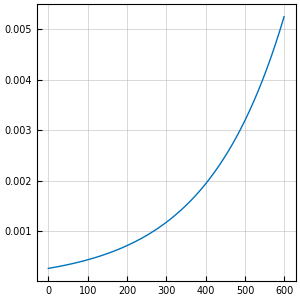

In [3]:
pulse_files, info_files = ft.get_files(dir_on, kid, pread, type=file_type)
nr_files = len(pulse_files)
f0, Q, Qc, Qi, S21_min, dt, T = ft.get_info(info_files[0])
sff = 1 / dt / 1e6
sw = int(lifetime * sff)
exp_filter = ft.get_window(filter_type, sw)
fig, ax = plt.subplots(figsize=(3,3),constrained_layout=True)
ax.plot(exp_filter)

In [4]:
amp, phase, _ = ft.get_data(pulse_files[:chuncksize])
signal = ft.coord_transformation(phase, amp, coord='circle', response='phase')

In [5]:
std = ft.get_sigma(signal, exp_filter)
ph = mph*std
pp = mpp*std
locs, props = ft.find_pks(signal, 2*ph[0], pp, exp_filter)
too_high_chunck = props['peak_heights'] >= ph[1]
args = np.argwhere(~too_high_chunck).flatten()
pulses, single_idx = ft.get_single_pulses(signal, locs, pw, pw_offset, args)
pulse_template = np.mean(pulses, axis=0)

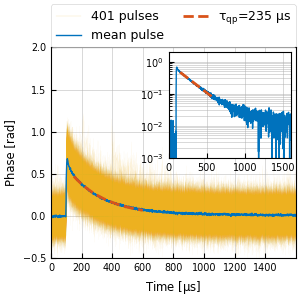

In [6]:
fig, ax = plt.subplots(constrained_layout=True, figsize=(3,3))
t = np.arange(0, pw+pw_offset, 1)
ax.plot(t, pulses.T, alpha=.2, lw=.1, c='y', label='_nolegend_')
ax.plot(t, pulses[0], lw=.1, c='y', label='%d pulses' % len(pulses))
ax.plot(t, pulse_template, label='mean pulse')
ax.set_xlim([t[0], t[-1]])
ax.set_ylim([-.5, 2])
ax.set_xlabel('Time [$\mu$s]')
ax.set_ylabel('Phase [rad]')
_ = ax.legend()

fit_tqp = [150,600]    
tqp, _, popt = ft.fit_decaytime(pulse_template, fit_tqp)
tqp /= sff
tqp_x = np.linspace(fit_tqp[0]/sff, fit_tqp[1]/sff, int((fit_tqp[1] - fit_tqp[0])))
fit_x = np.arange(len(tqp_x))
tqp_y = ft.exp_decay(fit_x, *popt)
ax.plot(tqp_x, tqp_y, ls='--', lw=2, label='$\\tau_{qp}$=%d $\mu$s' % tqp, zorder=3)
ax.legend(bbox_to_anchor=(0., 1, 1., .102), loc='lower left',
        ncols=2, mode="expand", borderaxespad=0., fontsize=9)
# BEGIN: Add inset with semilogy axes

ax_inset = inset_axes(ax, width="50%", height="50%", loc='upper right')
ax_inset.plot(t, pulse_template, label='mean pulse')
ax_inset.set_xlim([t[0], t[-1]])
ax_inset.set_ylim([1e-3, 2])
ax_inset.set_yscale('log')
# ax_inset.set_xlabel('Time [$\mu$s]')
# ax_inset.set_ylabel('Phase [rad]')
ax_inset.plot(tqp_x, tqp_y, ls='--', lw=2, label='$\\tau_{qp}$=%d $\mu$s' % tqp, zorder=3)
# END: Add inset with semilogy axes

In [7]:
noise_files, _ = ft.get_files(dir_off, kid, pread, type=file_type)
amp, phase, _ = ft.get_data(noise_files[:chuncksize])
noise = ft.coord_transformation(phase, amp, coord='circle', response='phase')

In [8]:
std = ft.get_sigma(noise, exp_filter)
ph = mph*std
pp = mpp*std
noise_locs, _ = ft.find_pks(noise, ph[0], pp, exp_filter)
noises = ft.get_single_noises(noise, noise_locs, pw+pw_offset)
_, noise_psd = ft.get_avg_psd(noises, pw+pw_offset, sff, exclude_dc=False, onesided=False)

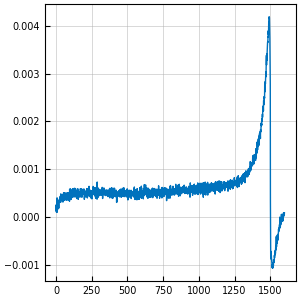

In [9]:
def opt_filter(mean_pulse, noise_psd, exclude_dc=True):      
    """
    optimal_filter computes the optimal filter that needs to be uploaded to the mux
    :param norm_pulse_fft:  numpy.ndarray, 1D complex array of pulse model
    :param noise_psd:       numpy.ndarray, 1D complex array of noise model
    :param exclude_dc:      bool, whether to exclude the DC value of the fft
    :return filter:         numpy.ndarray, 1D comlex array of normalised optimal filter
    """
    norm_pulse = mean_pulse / np.amax(mean_pulse)
    norm_pulse_fft = fft(norm_pulse)
    filter = norm_pulse_fft.conj()/noise_psd
    return ifft(filter)

opt_filter = ft.opt_filter(pulse_template, noise_psd, exclude_dc=False).real
opt_filter /= np.sum(opt_filter)
fig, ax = plt.subplots(constrained_layout=True, figsize=(3,3))
ax.plot(opt_filter)

Text(0, 0.5, 'Phase [rad]')

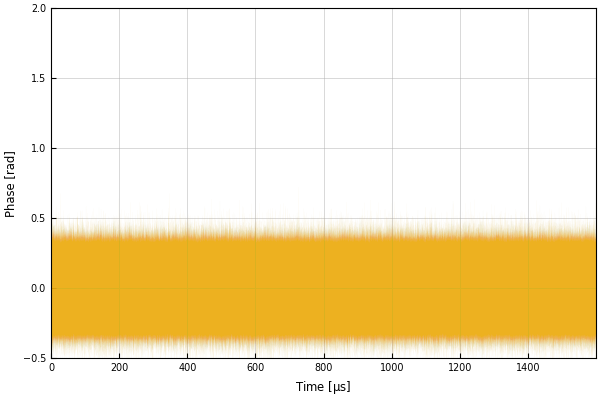

In [10]:
fig, ax = plt.subplots(constrained_layout=True, figsize=(6,4))
t = np.arange(0, pw+pw_offset, 1)
ax.plot(t, noises.T, alpha=.1, lw=.1, c='y')
# ax.plot(t, pulse_template)
ax.set_xlim([t[0], t[-1]])
ax.set_ylim([-.5, 2])
ax.set_xlabel('Time [$\mu$s]')
ax.set_ylabel('Phase [rad]')

In [11]:
def get_pulses(pulse_files, ph, pp, pw, pw_offset, chuncksize, nr_chuncks, window):
    if nr_chuncks:
        nr_req_files = np.amin((chuncksize * nr_chuncks, nr_files))
    else:
        nr_req_files = nr_files
    analysed_files = 0
    pulses = []
    single_idx = []
    too_high_idx = []
    single_locs = []
    while analysed_files < nr_req_files:
        if analysed_files + chuncksize > nr_files:
            chuncksize = nr_files - analysed_files
        amp, phase, _ = ft.get_data(pulse_files[analysed_files:analysed_files+chuncksize])
        signal = ft.coord_transformation(phase, amp, coord='circle', response='phase')
        len_file = int(len(signal) / chuncksize)
        locs, props = ft.find_pks(signal, ph, pp, window)
        # too_high_chunck = props['peak_heights'] >= ph[1]
        args = np.argwhere(~too_high_chunck).flatten()
        args = np.arange(len(locs), dtype=int)
        pulses_chunck, single_idx_chunck = ft.get_single_pulses(signal, locs, pw, pw_offset, args)
        if len(pulses_chunck):
            pulses.append(pulses_chunck)
            single_idx.append(single_idx_chunck)
            too_high_idx.append(too_high_chunck)
            single_locs.append(locs[single_idx_chunck] + len_file*analysed_files)
        analysed_files += chuncksize
        print('Analysed %d out of %d files' % (analysed_files, nr_req_files), end='\r')
    single_idx = np.hstack(single_idx)
    pulses = np.vstack(pulses)
    too_high_idx = np.hstack(too_high_idx)
    single_locs = np.hstack(single_locs)
    return pulses, single_idx, too_high_idx, single_locs


In [12]:
std = ft.get_sigma(noise, exp_filter)
nr_stds = [14]
H_opts = []
nr_chuncks = [None, None]
for i, nr_std in enumerate(nr_stds):
    ph = nr_std * std
    pp = nr_std * std
    pulses, _, _, _ = get_pulses(pulse_files, ph, pp, pw, pw_offset, 50, nr_chuncks[i], exp_filter)
    H_opt, R_sn, _, _ = ft.optimal_filter(pulses, pulse_template, sff*1e6, 1, noise_psd)
    print(R_sn)
    H_opts.append(H_opt)

6.791621675545631of 200 files


In [56]:
freqs, noise_psd = ft.get_avg_psd(noises, pw+pw_offset, sff, exclude_dc=False, onesided=True)
freqs, pulse_psd = ft.get_avg_psd(pulses, pw+pw_offset, sff, exclude_dc=False, onesided=True)

norm_pulse = pulse_template / np.amax(pulse_template)
sf = 1e6
N = len(norm_pulse)
L = int(N/2+1)
df = sf/N
pulse_psd = 1/(1e6*N)*np.abs(fft(pulse_template)[:L])**2
pulse_psd[1:L-1] *= 2
norm_psd = 1/(1e6*N)*np.abs(fft(norm_pulse)[:L])**2
norm_psd[1:L-1] *= 2
pulses_psd = 1/(1e6*N)*np.abs(fft(pulses)[:, :L])**2
pulses_psd[:, 1:L-1] *= 2
noises_psd = 1/(1e6*N)*np.abs(fft(noises)[:, :L])**2
noises_psd[:, 1:L-1] *= 2
avg_psd_noises = np.mean(noises_psd, axis=0)
avg_psd_pulses = np.mean(pulses_psd, axis=0)
freqs = np.arange(0, sf/2+df, df)

Rsn = np.mean(H_opt)/2.355 * np.sqrt(np.sum(2*avg_psd_noises/avg_psd_pulses))
Rsn


np.float64(11.585337834337736)

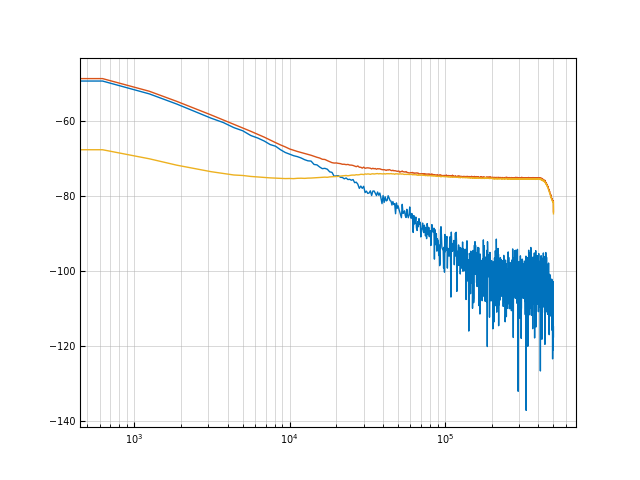

In [57]:
fig, ax = plt.subplots()
# ax.semilogx(freqs, 10*np.log10(noise_psd), label='Noise PSD')
ax.semilogx(freqs, 10*np.log10(pulse_psd), label='Noise PSD')
ax.semilogx(freqs, 10*np.log10(avg_psd_pulses), label='Noise PSD')
ax.semilogx(freqs, 10*np.log10(avg_psd_noises), label='Noise PSD')

4.8251374156984586


Text(0.5, 1.0, '8.5 $\\mu$m')

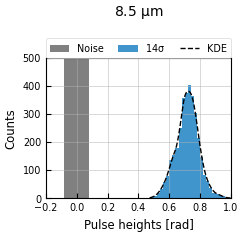

In [13]:
fig, axes = plt.subplot_mosaic('a', constrained_layout=True, figsize=(18.5/3/2.54, 6/2.54))
ax = axes['a']
binsize = 0.02
bins=np.arange(-.5, 2, binsize)
ax.hist(fftconvolve(noises.flatten(), opt_filter, mode='valid'), bins=bins, facecolor='gray', label='Noise', zorder=0)
colors = ['b', 'y', 'o', 'p'] 
for i, H_opt in enumerate(H_opts):
    _ = ax.hist(H_opt, bins=bins, facecolor=colors[i],alpha=.75, label='%d$\sigma$' % (nr_stds[i]), zorder=i)

ax.set_ylim([0, 500])
ax.set_xlim([-.2,1])
ax.set_ylabel('Counts')
ax.set_xlabel('Pulse heights [rad]')

H_opt = H_opts[-1]
R_opt, pdf_y, pdf_x, _, _ = ft.resolving_power(H_opt, binsize)
print(R_opt)
ax.plot(pdf_x, pdf_y, c='k', ls='--', label='KDE', lw=1)

ax.legend(bbox_to_anchor=(0., 1, 1., .102), loc='lower left',
        ncols=3, mode="expand", borderaxespad=0.)
ax.set_title('8.5 $\mu$m', pad=30, fontsize=10)
# plt.savefig('resolving power 85umv5.pdf')


4.828693635481815
4.830673688816619
4.829306395812284
4.827999813878299
4.832571556766334
4.831980589615042
4.830675238033864
4.8305029265694595
4.831096359952595
4.829120373326034
4.8283908015988315
4.833180038947183
4.82405092315477
4.82636834257559
4.830139862732779
4.8251374156984586
4.8241270539183745
4.830622241816145
4.829162804654633
4.821508441019771
4.82423455852634
4.821395246474699
4.831794317662049
4.83744469853089
4.8196530153827215
4.8368204674059365
4.831703467967677
4.822037634183617
4.829074349749805
4.834459469537477
4.8367773796937374
4.837028522751507
4.833985711425905
4.828603055157934
4.82080518866531
4.837470542772417
4.824686800837243
4.836719046815394
4.819748816112566
4.830515916886624
4.836314333669138
4.810594130876934
4.814996316177163
4.819280363811071
4.822608619502008
4.822599200317339
4.820706759726568
4.81950882064842
4.815063889635121
4.8084040411320395
4.8428262782455755
4.833462239403359
4.8281920339102
4.816173786800232
4.804619116737236
4.8327902

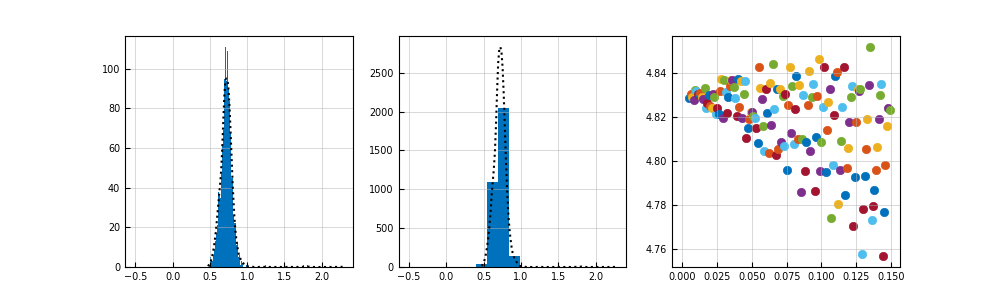

In [30]:
def single_gaussian(x, mu1, sigma1, A1):
    return A1 * norm.pdf(x, mu1, sigma1)

binsizes = np.arange(0.005, 0.15, 0.001)
Rs = []
fig, axes = plt.subplot_mosaic('abc', figsize=(10,3))
for i, binsize  in enumerate(binsizes):
    bins=np.arange(-.5, 2, binsize)
    R, pdf_y, pdf_x, _, _ = ft.resolving_power(H_opt, binsize)
    Rs.append(R)
    if i==0:
        ax = axes['a']
        ax.hist(H_opt, bins=bins, zorder=0)
        ax.plot(pdf_x, pdf_y, c='k', ls=':', label='KDE', lw=1.5)
    if i==len(binsizes)-1:
        ax = axes['b']
        ax.hist(H_opt, bins=bins, zorder=0)
        ax.plot(pdf_x, pdf_y, c='k', ls=':', label='KDE', lw=1.5)
    print(R)
    ax = axes['c']
    ax.scatter(binsize, R)
print(np.mean(Rs), np.sqrt(1/12*(np.amax(Rs)-np.amin(Rs))**2), np.std(Rs))
axes['c'].plot(np.mean(Rs))
axes['c'].plot(np.mean(Rs))